# Import Packages

In [23]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path       
import networkx as nx
import torch
from torch_geometric.data import Data
import torch.nn.functional as F
from torch_geometric.nn import GINEConv
from matplotlib.lines import Line2D


# Prepare Data

In [2]:
root_dir = Path("statsbomb_data")
threesixty_dir = root_dir / "data" / "three-sixty"

all_360 = []

for f in threesixty_dir.glob("*.json"):
    match_id = int(f.stem)

    try:
        data = json.loads(f.read_text(encoding="utf-8"))
        df = pd.DataFrame(data)
        df["match_id"] = match_id
        all_360.append(df)
    except:
        continue

threesixty_df = pd.concat(all_360, ignore_index=True)

In [3]:
threesixty_matches = threesixty_df.match_id.to_list()

events_dir = root_dir / "data" / "events"

all_events = []
for f in events_dir.glob("*.json"):
    match_id = int(f.stem)
    if match_id in threesixty_matches:
        data = json.loads(f.read_text(encoding="utf-8"))
        df = pd.DataFrame(data)
        df["match_id"] = match_id
        all_events.append(df)

events_df = pd.concat(all_events, ignore_index=True)


In [4]:
events_full = events_df.merge(
    threesixty_df,
    left_on="id",
    right_on="event_uuid",
    how="inner",
    suffixes=("", "_360")
)

In [5]:
# Load competitions
competitions_df = pd.read_json(root_dir / "data" / "competitions.json")

# Load ALL matches
matches_dir = root_dir / "data" / "matches"
match_dfs = []

for comp_dir in matches_dir.iterdir():
    if not comp_dir.is_dir():
        continue
    for season_file in comp_dir.glob("*.json"):
        df = pd.read_json(season_file)
        match_dfs.append(df)

matches_df = pd.concat(match_dfs, ignore_index=True)


In [6]:
events_full['event_type'] = events_full['type'].str.get('name')
pass_events = events_full.copy()[events_full['event_type']=='Pass']
pass_events['end_location'] = pass_events['pass'].str.get('end_location')
#pass_events = pass_events[['event_uuid', 'match_id', 'index', 'period','type', 'timestamp', 'end_location', 'freeze_frame']]
pass_events = pass_events.merge(matches_df[['match_id', 'match_date', 'competition', 'season', 'home_team', 'away_team']], on = 'match_id', how = 'left')

In [14]:
# build event type vocabulary mapping
events_full['event_type'] = events_full['type'].apply(lambda x: x['name'])
event_types = sorted(events_full['event_type'].unique())
event_type_to_idx = {et: i for i, et in enumerate(event_types)}
num_event_types = len(event_types)

# Conceptual Breakdown
- one training example = one pass event
- we know who the actor is, what kind of event it is, where all the visible players are on the field
- we want to predict where the ball ends up
$$\text{player + relations at time } t \rightarrow \text{ball location at } t+\varepsilon$$

- each node = one player in freeze frame
    - node features: [x_position, y_position, is_teammate, is_actor, is_keeper]
- edges describe player relationships
    - [distance, is_proximity=(0,1), is_pressure=(0,1), is_support=(0,1)]
- Event-type is embedded only in actor node

- model of choice: GINEConv, which is edge-aware

# Build Graphs

In [ ]:
# helper function
def euclidean(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)


def build_nodes(freeze_frame):
    node_features = []
    actor_idx = None

    for i, p in enumerate(freeze_frame):
        x, y = p["location"]

        # binary features of available information
        is_teammate = int(p["teammate"])
        is_actor = int(p["actor"])
        is_keeper = int(p["keeper"])

        if is_actor:
            actor_idx = i # maps node to player

        node_features.append([
            x, y,
            is_teammate,
            is_actor,
            is_keeper
        ])

    if actor_idx is None:
        raise ValueError("No actor in freeze_frame")

    x = torch.tensor(node_features, dtype=torch.float)
    return x, actor_idx


def proximity_edges(freeze_frame, threshold=8.0):
    # add edges between players who are close together on the pitch
    # threshold: distance in meters under which two players are considered close and should have an edge
    edges, attrs = [], []

    # loop over every unique pair of players and compute distance
    for i in range(len(freeze_frame)):
        for j in range(i + 1, len(freeze_frame)):
            d = euclidean(
                freeze_frame[i]["location"],
                freeze_frame[j]["location"]
            )

            if d < threshold:
                edges += [[i, j], [j, i]] # add edges in both directions
                attrs += [[d, 1, 0, 0], [d, 1, 0, 0]] # d = actual distance between players, is_proximity = 1, is_pressure = 0, is_support = 0

    return edges, attrs


def pressure_edges(freeze_frame, actor_idx):
    # connect opponents to the actor to represent pressure on actor
    edges, attrs = [], []
    actor_loc = freeze_frame[actor_idx]["location"] # location of player

    # loop over players in frame, select only opponents and compute distance
    for i, p in enumerate(freeze_frame):
        if not p["teammate"]:
            d = euclidean(p["location"], actor_loc) 
            edges.append([i, actor_idx]) # directed edge from defender -> actor
            attrs.append([d, 0, 1, 0]) # d = distance between defender and actor, is_proximity = 0, is_pressure = 1, is_support = 0

    return edges, attrs

def support_edges(freeze_frame, actor_idx):
    # connects actor to teammates to represent passing options
    # we only consider forward passes to be progressive/supportive i.e. players who can possibly advance the play
    edges, attrs = [], []

    actor_x = freeze_frame[actor_idx]["location"][0]
    actor_loc = freeze_frame[actor_idx]["location"] # location of actor

    for i, p in enumerate(freeze_frame):
        if p["teammate"] and not p["actor"]: # check if teammate is ahead of actor (horizontal distance)
            if p["location"][0] > actor_x:
                d = euclidean(actor_loc, p["location"])
                edges.append([actor_idx, i])# directed edge from actor -> teammate
                attrs.append([d, 0, 0, 1]) # d = distance between actor and teammate, is_proximity = 0, is_pressure = 0, is_support = 1

    return edges, attrs



def build_event_graph(event_row, event_type_to_idx, proximity_threshold=8.0):
    freeze_frame = event_row["freeze_frame"]
    

    # Nodes
    x, actor_idx = build_nodes(freeze_frame)

    # Store event type
    event_type = event_row['type']['name']
    event_type_idx = event_type_to_idx[event_type]
    

    edge_list, edge_attr = [], []

    e, a = proximity_edges(freeze_frame, proximity_threshold)
    edge_list += e
    edge_attr += a

    e, a = pressure_edges(freeze_frame, actor_idx)
    edge_list += e
    edge_attr += a

    e, a = support_edges(freeze_frame, actor_idx)
    edge_list += e
    edge_attr += a


    if len(edge_list) == 0:
        # freeze frames with no valid edges
        return None
    
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()


    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Store actor player_id
    actor_player_id = event_row['player']['id']

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        actor_idx=torch.tensor([actor_idx]), # represents event player
        actor_player_id=torch.tensor([actor_player_id]),
        event_type_idx=torch.tensor([event_type_idx]) # encodes what action the actor is taking
    )


def get_actor_info(graph, players_df):
    actor_idx = graph.actor_idx.item()
    actor_id = graph.actor_player_id.item()
    
    # Lookup name
    actor_name = players_df.loc[players_df['player']['id'] == actor_id, 'player_name'].values[0]
    
    return actor_idx, actor_id, actor_name


In [16]:
def pyg_to_nx(graph):
    G = nx.DiGraph()  # directed graph 
    
    # Add nodes with attributes
    for i, node_feat in enumerate(graph.x):
        G.add_node(
            i,
            x=node_feat[0].item(),
            y=node_feat[1].item(),
            is_teammate=bool(node_feat[2].item()),
            is_actor=bool(node_feat[3].item())
        )
    
    # Add edges with attributes
    for src, dst, attr in zip(graph.edge_index[0], graph.edge_index[1], graph.edge_attr):
        G.add_edge(
            src.item(),
            dst.item(),
            distance=attr[0].item(),
            is_proximity=bool(attr[1].item()),
            is_pressure=bool(attr[2].item()),
            is_support=bool(attr[3].item())
        )
    return G


def plot_event_graph(graph, title="Event Graph"):
    G = pyg_to_nx(graph)

    plt.figure(figsize=(12, 8))

    # Node positions
    pos = {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in G.nodes()}

    node_colors = []
    node_sizes = []
    for n in G.nodes():
        if G.nodes[n]['is_actor']:
            node_colors.append('red')
            node_sizes.append(200)
        elif G.nodes[n]['is_teammate']:
            node_colors.append('green')
            node_sizes.append(150)
        else:
            node_colors.append('blue')
            node_sizes.append(150)

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.9
    )

    # Draw edges
    proximity_edges = [(u, v) for u, v, d in G.edges(data=True) if d['is_proximity']]
    nx.draw_networkx_edges(G, pos, edgelist=proximity_edges, edge_color='gray', style='solid', width=1)

    pressure_edges = [(u, v) for u, v, d in G.edges(data=True) if d['is_pressure']]
    nx.draw_networkx_edges(G, pos, edgelist=pressure_edges, edge_color='orange', style='dashed', width=2)

    support_edges = [(u, v) for u, v, d in G.edges(data=True) if d['is_support']]
    nx.draw_networkx_edges(G, pos, edgelist=support_edges, edge_color='purple', style='solid', width=3)

    actor_idx = graph.actor_idx.item()
    actor_name = graph.actor_player_name

    nx.draw_networkx_labels(
        G,
        pos,
        labels={actor_idx: actor_name},
        font_color='black',
        font_size=10
    )

    nx.draw_networkx_labels(G, pos, {n: n for n in G.nodes()}, font_size=8)

    plt.title(title)
    plt.xlabel("Pitch X")
    plt.ylabel("Pitch Y")
    plt.xlim(0, 120)  # StatsBomb pitch length
    plt.ylim(0, 80)   # StatsBomb pitch width
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()


In [ ]:
graphs = []

for _, row in pass_events.iterrows():
    g = build_event_graph(row, event_type_to_idx)

    if g is None:
        continue

    g.actor_player_id = row["player"]["id"]
    g.actor_player_name = row["player"]["name"]
    g.event_type_name = row["type"]["name"]
    g.match_id = row["match_id"]

    graphs.append(g)


In [97]:
def plot_event_graph_ax(graph, ax, title=""):
    G = pyg_to_nx(graph)  # convert PyG graph to NetworkX

    # Node positions
    pos = {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in G.nodes()}

    node_colors, node_sizes = [], []
    for n in G.nodes():
        if G.nodes[n]['is_actor']:
            node_colors.append('red')
            node_sizes.append(200)
        elif G.nodes[n]['is_teammate']:
            node_colors.append('green')
            node_sizes.append(150)
        else:
            node_colors.append('blue')
            node_sizes.append(150)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)


    # Draw edges
    proximity_edges_ = [(u, v) for u, v, d in G.edges(data=True) if d['is_proximity']]
    nx.draw_networkx_edges(G, pos, edgelist=proximity_edges_, edge_color='gray', style='solid', width=1, ax=ax)

    pressure_edges_ = [(u, v) for u, v, d in G.edges(data=True) if d['is_pressure']]
    nx.draw_networkx_edges(G, pos, edgelist=pressure_edges_, edge_color='orange', style='dashed', width=2, ax=ax)

    support_edges_ = [(u, v) for u, v, d in G.edges(data=True) if d['is_support']]
    nx.draw_networkx_edges(G, pos, edgelist=support_edges_, edge_color='purple', style='solid', width=3, ax=ax)

    # Labels for all nodes
    nx.draw_networkx_labels(G, pos, labels={n: str(n) for n in G.nodes()}, font_size=8, font_color='black', ax=ax)

    # Add legend for edge types


    # Pitch limits
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

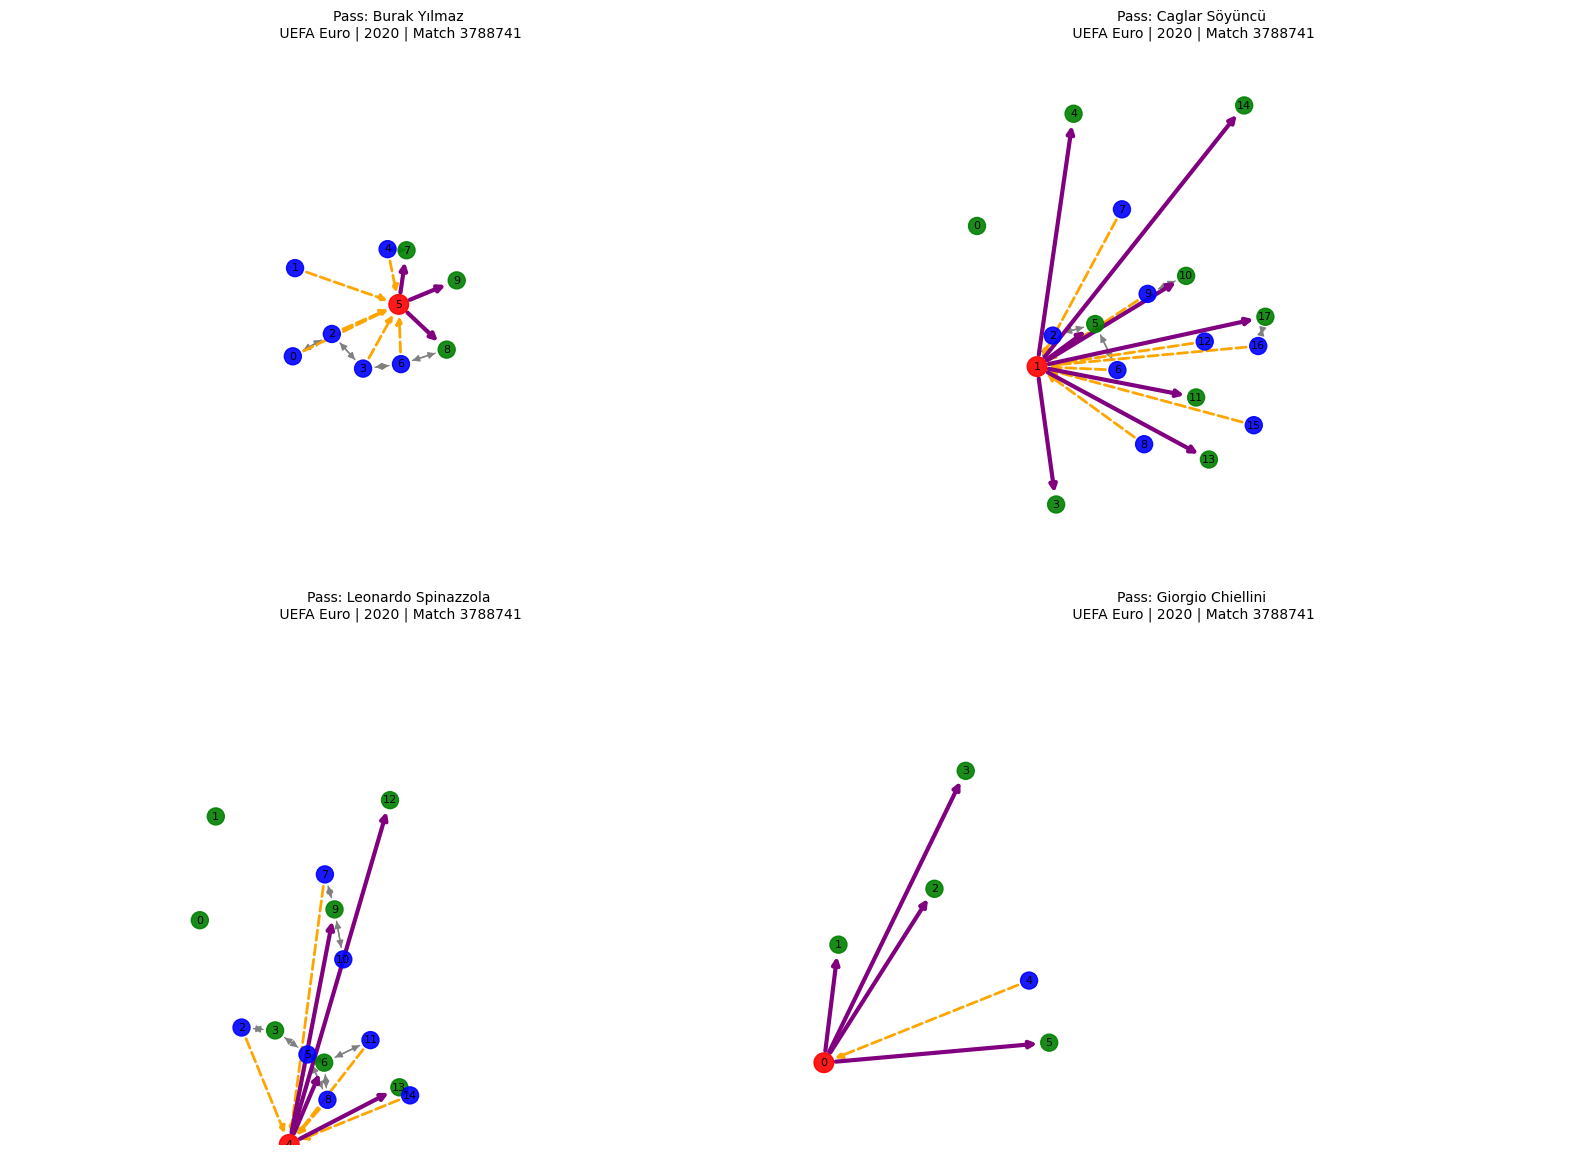

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i in range(4):
    event_graph = graphs[i]
    competition_name = pass_events.iloc[i].competition.get('competition_name')
    season_name = pass_events.iloc[i].season.get('season_name')
    match_num = pass_events.iloc[i].match_id
    event_type = pass_events.iloc[i].type['name']
    title = f"{event_type}: {event_graph.actor_player_name}\n {competition_name} | {season_name} | Match {match_num}"
    plot_event_graph_ax(event_graph, axes[i], title)

plt.tight_layout()
plt.show()

# Model

Goal: Given a pass event + 360 freeze-frame context, predict the end location of the ball (x_end, y_end) for successful passes
$$\text{event graph at pass time} \rightarrow \mathbb{R}^2$$

In [ ]:
class PassPredictionGNN(torch.nn.Module):
    def __init__(
        self,
        node_dim,
        edge_dim,
        num_event_types,
        hidden_dim=64,
        out_dim=64
    ):
        super().__init__()

        # Event type embedding
        # is it weird that this is going from num_event_types to hidden_dim which is larger than types?
        self.event_emb = torch.nn.Embedding(num_event_types, hidden_dim)

        # Node projection
        # what is this doing?
        self.node_proj = torch.nn.Linear(node_dim, hidden_dim)

        # GNN layers
        self.conv1 = GINEConv(
            torch.nn.Sequential(
                torch.nn.Linear(hidden_dim, hidden_dim),
                torch.nn.ReLU()
            ),
            edge_dim=edge_dim
        )

        self.conv2 = GINEConv(
            torch.nn.Sequential(
                torch.nn.Linear(hidden_dim, out_dim),
                torch.nn.ReLU()
            ),
            edge_dim=edge_dim
        )

        # Regression head
        self.pass_head = torch.nn.Sequential(
            torch.nn.Linear(out_dim, out_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(out_dim, 2)  # (x_end, y_end)
        )

    def forward(self, x, edge_index, edge_attr, actor_idx, event_type_idx):
        # Project nodes
        x = self.node_proj(x)

        # Inject event type into actor node
        event_vec = self.event_emb(event_type_idx)
        x[actor_idx] = x[actor_idx] + event_vec.squeeze(0)

        # Message passing- 
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_attr)

        # Actor node embedding
        actor_emb = x[actor_idx]          # [1, out_dim]

        # Predict pass end location
        # Standard MLP, maps decision state → (x_end, y_end)
        pass_end = self.pass_head(actor_emb)  # [1, 2]

        return pass_end, x


# Build out Train/Test Split

In [100]:
matches = pass_events.match_id.unique()
np.random.shuffle(matches)

split = int(0.8 * len(matches)) # train on 80% of matches, test on unseen matches
train_matches = set(matches[:split])
test_matches  = set(matches[split:])

In [101]:
train_data = []
test_data = []

for graph, row in zip(graphs, pass_events.itertuples()):
    item = (graph, row)

    if row.match_id in train_matches:
        train_data.append(item)
    else:
        test_data.append(item)


In [102]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PassPredictionGNN(
    node_dim=graphs[0].x.shape[1],
    edge_dim=graphs[0].edge_attr.shape[1],
    num_event_types=num_event_types,
    hidden_dim=64,
    out_dim=64
).to(device)

In [103]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 5
for epoch in range(epochs):
    model.train()
    train_loss = 0

    for graph, row in train_data:
        
        target = torch.tensor(
            row.end_location,
            dtype=torch.float,
            device=device
        ).unsqueeze(0)

        optimizer.zero_grad()

        pred_xy, _ = model(
            graph.x.to(device),
            graph.edge_index.to(device),
            graph.edge_attr.to(device),
            graph.actor_idx.to(device),
            graph.event_type_idx.to(device)
        )

        loss = criterion(pred_xy, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch} | Train loss: {train_loss / len(train_data):.4f}")


Epoch 0 | Train loss: 683.5995


KeyboardInterrupt: 

In [ ]:
model.eval()

errors = []
preds = []
trues = []

with torch.no_grad():
    for graph, row in test_data:
        target = torch.tensor(
            row.end_location,
            dtype=torch.float,
            device=device
        ).unsqueeze(0)

        pred_xy, _ = model(
            graph.x.to(device),
            graph.edge_index.to(device),
            graph.edge_attr.to(device),
            graph.actor_idx.to(device),
            graph.event_type_idx.to(device)
        )

        error = torch.norm(pred_xy - target, dim=1).item()

        errors.append(error)
        preds.append(pred_xy.cpu().numpy()[0])
        trues.append(target.cpu().numpy()[0])

print(f"Mean error (meters): {np.mean(errors):.2f}")


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()

for graph, row in zip(graphs, pass_events.itertuples()):
    target = torch.tensor(
        row.location,
        dtype=torch.float,
        device=device
    ).unsqueeze(0)

    optimizer.zero_grad()

    pred_xy, _ = model(
        graph.x.to(device),
        graph.edge_index.to(device),
        graph.edge_attr.to(device),
        graph.actor_idx.to(device),
        graph.event_type_idx.to(device)
    )

    loss = criterion(pred_xy, target)
    loss.backward()
    optimizer.step()


In [ ]:
true_x, true_y = target.cpu().numpy()[0]
pred_x, pred_y = pred_xy.detach().cpu().numpy()[0]

plt.scatter(true_x, true_y, c="green", label="True")
plt.scatter(pred_x, pred_y, c="red", label="Pred")
plt.legend()
plt.xlim(0, 120)
plt.ylim(0, 80)
plt.gca().set_aspect("equal")
plt.title("Pass End Location Prediction")
plt.show()
